# Forest Fire Impact Prediction with a Two-Stage Hurdle Model

This project predicts forest-fire impact using meteorological conditions, Fire Weather Index measurements, location and calendar information.

The burned-area target contains many zero values and a small number of extremely large fires. A single ordinary regression model may struggle with this mixture.

A two-stage hurdle-style model is therefore developed:

1. Classify whether the burned area will be greater than zero.
2. Estimate the burned area for observations that pass this hurdle.
3. Combine probability and severity into an expected burned-area prediction.

This is supervised learning because the known burned-area measurements provide targets for both stages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, mean_absolute_error, mean_squared_error,
    median_absolute_error, r2_score
)

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Dataset

The Forest Fires dataset contains observations collected from Montesinho Natural Park in Portugal.

The predictors include:

- Spatial coordinates
- Month and day
- Fine Fuel Moisture Code (FFMC)
- Duff Moisture Code (DMC)
- Drought Code (DC)
- Initial Spread Index (ISI)
- Temperature
- Relative humidity
- Wind speed
- Rainfall

The target `area` represents burned area in hectares.

An area of zero should be interpreted as no measurable burned area in the dataset, not necessarily proof that no ignition occurred.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/forest-fires/forestfires.csv"

df = pd.read_csv(DATA_URL)
df["measurable_burn"] = (df["area"] > 0).astype(int)
df["log_area"] = np.log1p(df["area"])

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
df.head()

Dataset shape: (517, 15)
Missing values: 0


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,measurable_burn,log_area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0,0.0


In [5]:
target_summary = pd.Series({
    "observations": len(df),
    "zero_area_records": (df["area"] == 0).sum(),
    "positive_area_records": (df["area"] > 0).sum(),
    "positive_percentage": 100 * df["measurable_burn"].mean(),
    "median_area": df["area"].median(),
    "mean_area": df["area"].mean(),
    "maximum_area": df["area"].max()
})

target_summary

observations              517.000000
zero_area_records         247.000000
positive_area_records     270.000000
positive_percentage        52.224371
median_area                 0.520000
mean_area                  12.847292
maximum_area             1090.840000
dtype: float64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25164\2127987377.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Zero area", "Positive area"])


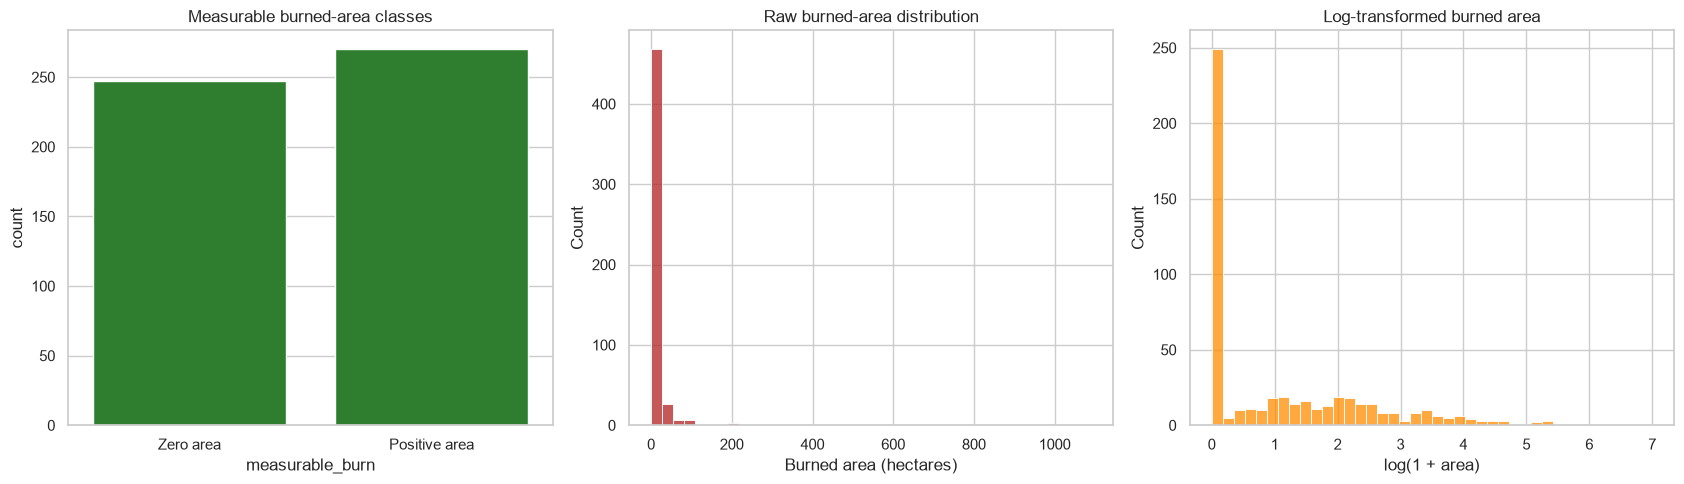

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.countplot(data=df, x="measurable_burn", ax=axes[0], color="forestgreen")
axes[0].set_title("Measurable burned-area classes")
axes[0].set_xticklabels(["Zero area", "Positive area"])

sns.histplot(df["area"], bins=40, ax=axes[1], color="firebrick")
axes[1].set_title("Raw burned-area distribution")
axes[1].set_xlabel("Burned area (hectares)")

sns.histplot(df["log_area"], bins=40, ax=axes[2], color="darkorange")
axes[2].set_title("Log-transformed burned area")
axes[2].set_xlabel("log(1 + area)")

plt.tight_layout()
plt.show()

In [7]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

monthly_summary = df.groupby("month").agg(
    observations=("area", "size"),
    measurable_rate=("measurable_burn", "mean"),
    median_area=("area", "median"),
    mean_area=("area", "mean")
).reindex(month_order)

monthly_summary

,observations,measurable_rate,median_area,mean_area
month,,,,
jan,2,0.000000,0.000,0.000000
feb,20,0.500000,0.550,6.275000
mar,54,0.351852,0.000,4.356667
apr,9,0.444444,0.000,8.891111
may,2,0.500000,19.240,19.240000
jun,17,0.470588,0.000,5.841176
jul,32,0.562500,1.035,14.369687
aug,184,0.538043,0.545,12.489076
sep,172,0.563953,1.360,17.942616


## Exploratory findings

- Total observations: **517**
- Zero-area observations: **247**
- Positive-area observations: **270**
- Percentage with measurable burned area: **52.22%**
- Median burned area: **0.52 hectares**
- Mean burned area: **12.85 hectares**
- Maximum burned area: **1,090.84 hectares**
- Missing values: **0**

The raw burned-area distribution is extremely right-skewed. Most observations have zero or very small burned areas, while a few exceptionally large fires extend beyond 1,000 hectares.

The large difference between the median of 0.52 hectares and mean of 12.85 hectares shows that a small number of extreme fires pull the average upward. The log transformation compresses these extreme values and produces a more manageable target distribution, although substantial skewness remains.

August and September contained 184 and 172 observations respectively, representing approximately 68.9% of the dataset. Their measurable-area rates were 53.80% and 56.40%. September also had a higher mean burned area of 17.94 hectares.

December had a 100% positive-area rate, but this was based on only nine observations. Similarly, May's high mean area was based on only two observations. These small monthly samples should not be treated as reliable seasonal evidence.

## 2. Train–test split and preprocessing

The data is split before model fitting to preserve an untouched test set.

Stratification maintains approximately the same proportion of zero and positive burned-area observations in both partitions.

Numerical features are standardised, while month and day are one-hot encoded. All preprocessing is fitted only to the training data through scikit-learn pipelines.

In [8]:
numeric_features = ["X", "Y", "FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
categorical_features = ["month", "day"]
feature_names = numeric_features + categorical_features

X = df[feature_names]
y_class = df["measurable_burn"]
y_area = df["area"]

X_train, X_test, y_train, y_test, area_train, area_test = train_test_split(
    X, y_class, y_area, test_size=0.25, stratify=y_class, random_state=SEED
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Training positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))

Training observations: 387
Test observations: 130
Training positive rate: 0.522
Test positive rate: 0.5231


In [9]:
def make_preprocessor():
    return ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ], sparse_threshold=0)

## 3. Stage one: measurable-burn classification

A Random Forest classifier estimates the probability that burned area will be greater than zero.

The decision threshold is selected using out-of-fold predictions from the training set. This avoids selecting the threshold directly on the test data.

The threshold is chosen to maximise balanced accuracy, with F1-score used to resolve ties.

In [10]:
classifier = Pipeline([
    ("preprocessing", make_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=600, min_samples_leaf=4, max_features="sqrt",
        class_weight="balanced_subsample", random_state=SEED, n_jobs=-1
    ))
])

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_probability = cross_val_predict(
    classifier, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

threshold_rows = []

for threshold in np.linspace(0.20, 0.80, 121):
    predictions = (oof_probability >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(y_train, predictions),
        "f1_score": f1_score(y_train, predictions)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_row = threshold_df.sort_values(
    ["balanced_accuracy", "f1_score"], ascending=False
).iloc[0]

best_threshold = best_row["threshold"]
print("Selected threshold:", round(best_threshold, 3))
best_row

Selected threshold: 0.475


threshold            0.475000
balanced_accuracy    0.532366
f1_score             0.594104
Name: 55, dtype: float64

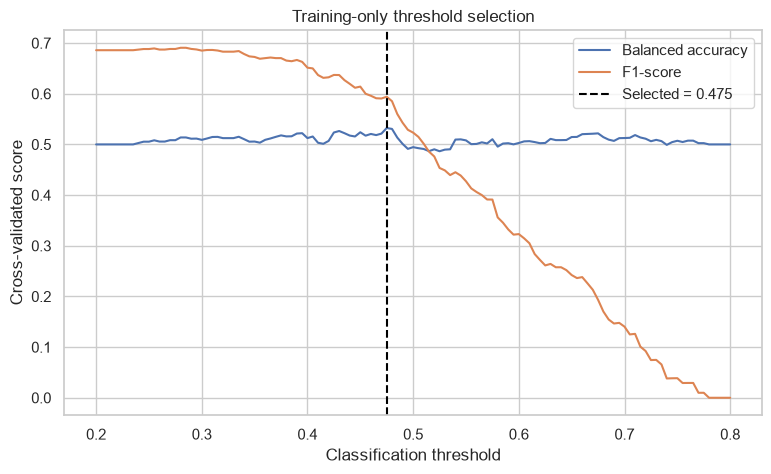

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], label="Balanced accuracy")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1-score")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Selected = {best_threshold:.3f}")
plt.xlabel("Classification threshold")
plt.ylabel("Cross-validated score")
plt.title("Training-only threshold selection")
plt.legend()
plt.show()

In [13]:
classifier.fit(X_train, y_train)

test_probability = classifier.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= best_threshold).astype(int)

baseline_probability = np.full(len(y_test), y_train.mean())
baseline_prediction = (baseline_probability >= 0.5).astype(int)

In [14]:
def classification_metrics(name, actual, prediction, probability):
    return {
        "model": name,
        "ROC-AUC": roc_auc_score(actual, probability),
        "PR-AUC": average_precision_score(actual, probability),
        "balanced_accuracy": balanced_accuracy_score(actual, prediction),
        "precision": precision_score(actual, prediction, zero_division=0),
        "recall": recall_score(actual, prediction, zero_division=0),
        "F1": f1_score(actual, prediction, zero_division=0),
        "Brier_score": brier_score_loss(actual, probability)
    }

classification_results = pd.DataFrame([
    classification_metrics("Class-prior baseline", y_test, baseline_prediction, baseline_probability),
    classification_metrics("Random Forest", y_test, test_prediction, test_probability)
])

classification_results.round(4)

,model,ROC-AUC,PR-AUC,balanced_accuracy,precision,recall,F1,Brier_score
0,Class-prior baseline,0.5000,0.5231,0.5000,0.5231,1.0000,0.6869,0.2495
1,Random Forest,0.6779,0.6836,0.5897,0.6027,0.6471,0.6241,0.2275


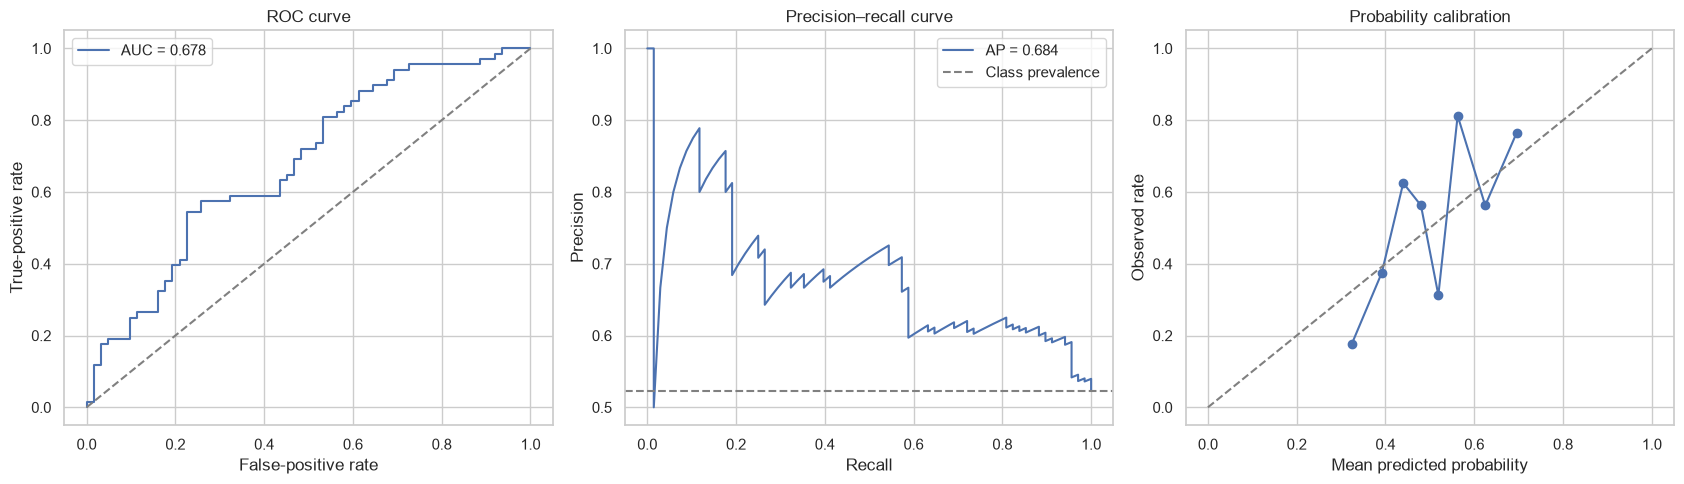

In [15]:
fpr, tpr, _ = roc_curve(y_test, test_probability)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probability)
observed_rate, predicted_rate = calibration_curve(y_test, test_probability, n_bins=8, strategy="quantile")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probability):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set(title="ROC curve", xlabel="False-positive rate", ylabel="True-positive rate")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"AP = {average_precision_score(y_test, test_probability):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label="Class prevalence")
axes[1].set(title="Precision–recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()

axes[2].plot(predicted_rate, observed_rate, marker="o")
axes[2].plot([0, 1], [0, 1], "--", color="grey")
axes[2].set(title="Probability calibration", xlabel="Mean predicted probability", ylabel="Observed rate")

plt.tight_layout()
plt.show()

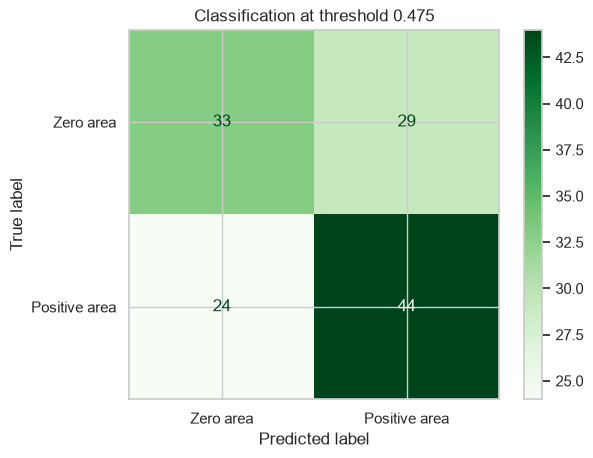

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test, test_prediction,
    display_labels=["Zero area", "Positive area"],
    cmap="Greens"
)

plt.title(f"Classification at threshold {best_threshold:.3f}")
plt.show()

## Stage-one classification results

- Selected probability threshold: **0.475**
- Training cross-validated balanced accuracy at this threshold: **0.5324**
- Test ROC-AUC: **0.6779**
- Test PR-AUC: **0.6836**
- Balanced accuracy: **0.5897**
- Precision: **0.6027**
- Recall: **0.6471**
- F1-score: **0.6241**
- Brier score: **0.2275**

The confusion matrix contained:

- True negatives: **33**
- False positives: **29**
- False negatives: **24**
- True positives: **44**

The Random Forest provided modest discrimination between zero and positive burned-area records. Its ROC-AUC of 0.6779 is above random performance, but it is not strong enough for reliable operational classification.

Compared with the class-prior baseline, the Random Forest improved ROC-AUC from 0.5000 to 0.6779, PR-AUC from 0.5231 to 0.6836, balanced accuracy from 0.5000 to 0.5897 and Brier score from 0.2495 to 0.2275.

The baseline obtained a higher F1-score of 0.6869 only because it classified every observation as positive, giving it perfect recall but no ability to recognise zero-area records. Therefore, its higher F1-score does not represent better balanced classification.

The calibration curve is irregular rather than consistently following the diagonal. Some probability ranges overestimated the observed rate while others underestimated it. This indicates imperfect and unstable calibration, partly because the test set contains only 130 observations.

Overall, measurable burned area was moderately difficult to classify using the available predictors.

## 4. Stage two: positive-area severity regression

The second model is trained only on training observations where burned area is greater than zero.

The target is transformed using:

\[
\log(1 + area)
\]

This reduces the influence of extremely large fires during training. Predictions are converted back into hectares using the inverse transformation.

In [17]:
positive_train = y_train == 1
positive_test = y_test == 1

severity_model = Pipeline([
    ("preprocessing", make_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=600, min_samples_leaf=3, max_features=0.8,
        random_state=SEED, n_jobs=-1
    ))
])

severity_model.fit(
    X_train.loc[positive_train],
    np.log1p(area_train.loc[positive_train])
)

conditional_log_prediction = severity_model.predict(X_test)
conditional_area_prediction = np.clip(np.expm1(conditional_log_prediction), 0, None)

In [18]:
positive_actual = area_test.loc[positive_test].to_numpy()
positive_prediction = conditional_area_prediction[positive_test.to_numpy()]
median_baseline = np.full(len(positive_actual), area_train.loc[positive_train].median())

def severity_metrics(name, actual, prediction):
    return {
        "model": name,
        "MAE_hectares": mean_absolute_error(actual, prediction),
        "median_AE": median_absolute_error(actual, prediction),
        "RMSE_hectares": np.sqrt(mean_squared_error(actual, prediction)),
        "R2_raw": r2_score(actual, prediction),
        "R2_log": r2_score(np.log1p(actual), np.log1p(prediction))
    }

severity_results = pd.DataFrame([
    severity_metrics("Positive-area median baseline", positive_actual, median_baseline),
    severity_metrics("Random Forest severity model", positive_actual, positive_prediction)
])

severity_results.round(4)

,model,MAE_hectares,median_AE,RMSE_hectares,R2_raw,R2_log
0,Positive-area median baseline,18.2563,4.4600,46.0584,-0.1201,-0.0368
1,Random Forest severity model,20.0028,7.6407,46.0547,-0.1200,-0.2374


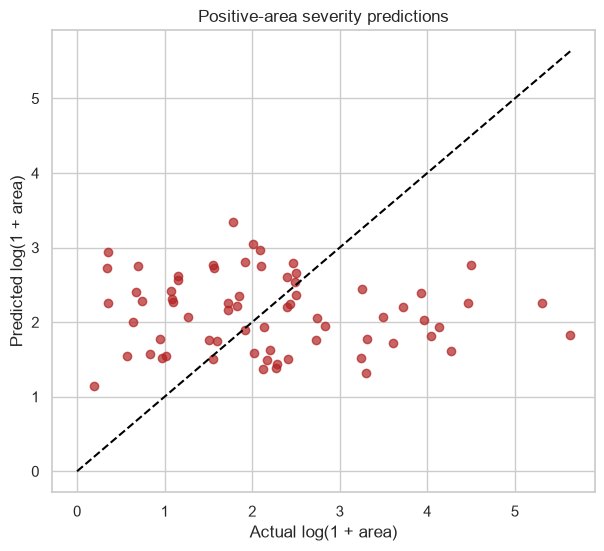

In [19]:
plt.figure(figsize=(7, 6))

plt.scatter(
    np.log1p(positive_actual),
    np.log1p(positive_prediction),
    alpha=0.7,
    color="firebrick"
)

limit = max(np.log1p(positive_actual).max(), np.log1p(positive_prediction).max())
plt.plot([0, limit], [0, limit], "--", color="black")
plt.xlabel("Actual log(1 + area)")
plt.ylabel("Predicted log(1 + area)")
plt.title("Positive-area severity predictions")
plt.show()

## Stage-two severity results

For test observations with positive burned area, the Random Forest severity model produced:

- MAE: **20.0028 hectares**
- Median absolute error: **7.6407 hectares**
- RMSE: **46.0547 hectares**
- Raw-scale R²: **−0.1200**
- Log-scale R²: **−0.2374**

The positive-area median baseline produced:

- MAE: **18.2563 hectares**
- Median absolute error: **4.4600 hectares**
- RMSE: **46.0584 hectares**
- Raw-scale R²: **−0.1201**
- Log-scale R²: **−0.0368**

The Random Forest performed worse than the median baseline on MAE, median absolute error and log-scale R². Its RMSE was only 0.0037 hectares lower, which is negligible.

Both R² values were negative. This means the severity model did not explain positive-area variation on the test set and performed worse than a simple test-set mean prediction under the R² definition.

The prediction plot shows regression toward the middle: small fires were frequently overestimated, while large fires were heavily underestimated. Predictions remained within a relatively narrow range even when the actual burned area became very large.

Therefore, the available weather, location and calendar predictors provided little reliable information about the final size of a positive-area fire in this test split.

## 5. Combining probability and severity

Two combined hurdle predictions are evaluated.

### Hard hurdle prediction

The severity prediction is used only when the classification probability exceeds the selected threshold. Otherwise, the predicted area is zero.

### Expected-area prediction

The conditional severity estimate is multiplied by the probability of measurable burning:

\[
E(area \mid X) =
P(area > 0 \mid X)
\times
E(area \mid area > 0, X)
\]

The expected prediction represents probability-weighted impact and is useful for planning under uncertainty.

In [20]:
hard_hurdle_prediction = np.where(
    test_probability >= best_threshold,
    conditional_area_prediction,
    0
)

expected_area_prediction = test_probability * conditional_area_prediction

single_regressor = Pipeline([
    ("preprocessing", make_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=600, min_samples_leaf=3, max_features=0.8,
        random_state=SEED, n_jobs=-1
    ))
])

single_regressor.fit(X_train, np.log1p(area_train))
single_area_prediction = np.clip(
    np.expm1(single_regressor.predict(X_test)),
    0,
    None
)

In [21]:
def overall_metrics(name, actual, prediction):
    return {
        "model": name,
        "MAE": mean_absolute_error(actual, prediction),
        "median_AE": median_absolute_error(actual, prediction),
        "RMSE": np.sqrt(mean_squared_error(actual, prediction)),
        "R2": r2_score(actual, prediction),
        "actual_total": actual.sum(),
        "predicted_total": prediction.sum()
    }

overall_results = pd.DataFrame([
    overall_metrics("Always predict zero", area_test, np.zeros(len(area_test))),
    overall_metrics("Single log-area Random Forest", area_test, single_area_prediction),
    overall_metrics("Hard hurdle", area_test, hard_hurdle_prediction),
    overall_metrics("Probability-weighted hurdle", area_test, expected_area_prediction)
])

overall_results.round(4)

,model,MAE,median_AE,RMSE,R2,actual_total,predicted_total
0,Always predict zero,11.0650,0.4300,34.9957,-0.1111,1438.45,0.0000
1,Single log-area Random Forest,11.3191,2.3411,34.3115,-0.0681,1438.45,349.2666
2,Hard hurdle,13.1770,4.5535,34.8361,-0.1010,1438.45,713.3654
3,Probability-weighted hurdle,12.4057,4.0452,34.2563,-0.0646,1438.45,613.8879


In [22]:
comparison = pd.DataFrame({
    "actual_area": area_test,
    "measurable_probability": test_probability,
    "conditional_severity": conditional_area_prediction,
    "hard_hurdle": hard_hurdle_prediction,
    "expected_hurdle": expected_area_prediction
}, index=X_test.index)

comparison["absolute_error"] = abs(
    comparison["actual_area"] - comparison["expected_hurdle"]
)

comparison.sort_values("absolute_error", ascending=False).head(10)

,actual_area,measurable_probability,conditional_severity,hard_hurdle,expected_hurdle,absolute_error
479,278.53,0.460759,5.232120,0.000000,2.410744,276.119256
236,200.94,0.441337,8.540643,0.000000,3.769298,197.170702
293,86.45,0.599390,8.521224,8.521224,5.107540,81.342460
230,88.49,0.492330,14.820497,14.820497,7.296569,81.193431
473,70.32,0.543855,4.029912,4.029912,2.191688,68.128312
469,61.13,0.472217,5.936431,0.000000,2.803284,58.326716
337,56.04,0.452047,5.135763,0.000000,2.321609,53.718391
395,51.78,0.445427,6.579029,0.000000,2.930479,48.849521
504,49.59,0.575016,9.911910,9.911910,5.699509,43.890491
498,40.54,0.680087,8.012728,8.012728,5.449354,35.090646


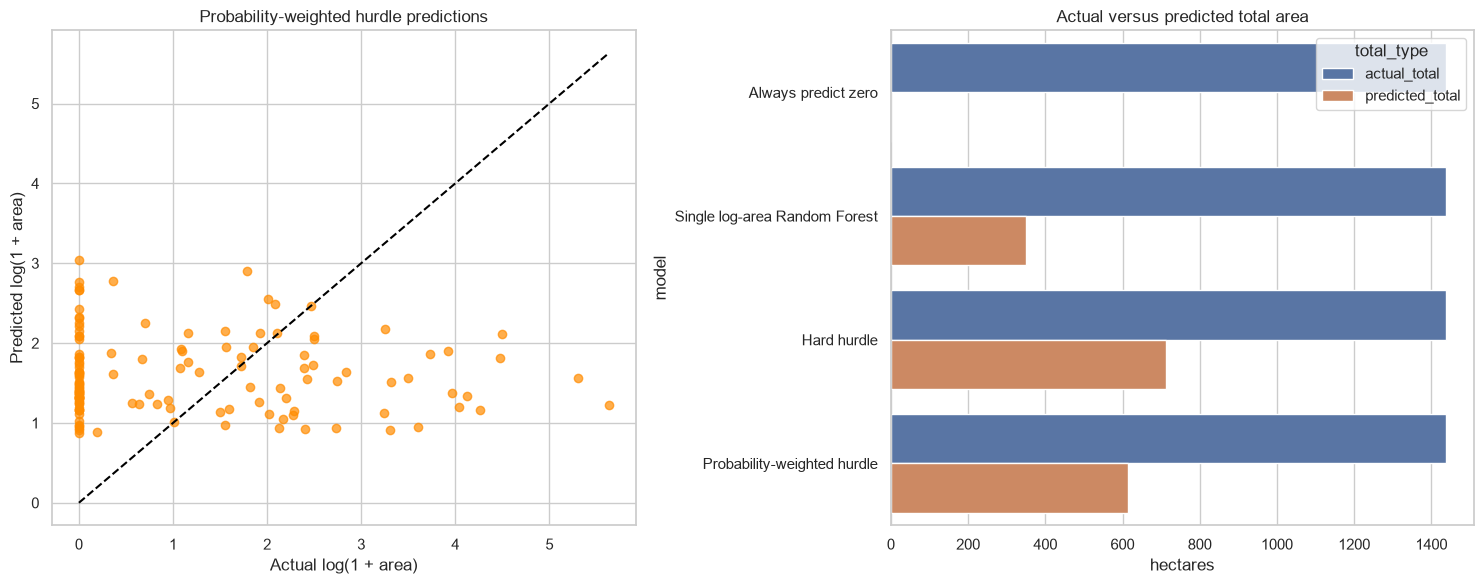

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(
    np.log1p(area_test),
    np.log1p(expected_area_prediction),
    alpha=0.7,
    color="darkorange"
)
limit = max(np.log1p(area_test).max(), np.log1p(expected_area_prediction).max())
axes[0].plot([0, limit], [0, limit], "--", color="black")
axes[0].set(
    title="Probability-weighted hurdle predictions",
    xlabel="Actual log(1 + area)",
    ylabel="Predicted log(1 + area)"
)

plot_df = overall_results.melt(
    id_vars="model",
    value_vars=["actual_total", "predicted_total"],
    var_name="total_type",
    value_name="hectares"
)

sns.barplot(data=plot_df, x="hectares", y="model", hue="total_type", ax=axes[1])
axes[1].set_title("Actual versus predicted total area")

plt.tight_layout()
plt.show()

## Combined hurdle model results

### Best results by metric

- Best MAE: **Always-zero baseline — 11.0650 hectares**
- Best median absolute error: **Always-zero baseline — 0.4300 hectares**
- Best RMSE: **Probability-weighted hurdle — 34.2563 hectares**
- Best R²: **Probability-weighted hurdle — −0.0646**
- Actual test-set burned area: **1,438.45 hectares**
- Probability-weighted predicted total: **613.89 hectares**

### Complete comparison

| Model | MAE | Median AE | RMSE | R² | Predicted total |
|---|---:|---:|---:|---:|---:|
| Always zero | 11.0650 | 0.4300 | 34.9957 | −0.1111 | 0.00 |
| Single Random Forest | 11.3191 | 2.3411 | 34.3115 | −0.0681 | 349.27 |
| Hard hurdle | 13.1770 | 4.5535 | 34.8361 | −0.1010 | 713.37 |
| Probability-weighted hurdle | 12.4057 | 4.0452 | 34.2563 | −0.0646 | 613.89 |

The probability-weighted hurdle achieved the lowest RMSE and least-negative R², slightly outperforming the single regression model on metrics that give greater weight to large errors. However, it performed worse on MAE and median absolute error.

The hard hurdle performed poorly because it assigned zero area whenever probability fell below 0.475. The two largest test fires, measuring 278.53 and 200.94 hectares, received probabilities of only 0.461 and 0.441 and were therefore assigned zero by the hard hurdle.

The probability-weighted model avoided setting these predictions completely to zero, but still predicted only 2.41 and 3.77 hectares. The severity model was consequently the main weakness.

The probability-weighted prediction captured only approximately 42.7% of the actual total burned area. It underestimated the total by approximately 824.56 hectares.

Separating measurable occurrence from severity produced a small RMSE improvement over the single model, but it did not improve MAE and did not solve the extreme-fire underestimation problem. All overall R² values were negative, so none of the models provided strong generalisable burned-area prediction.

## 6. Permutation feature importance

Permutation importance measures how much model performance decreases when one feature is randomly shuffled.

Unlike the Random Forest's internal importance, this procedure evaluates the complete preprocessing and modelling pipeline on unseen test data.

Importance does not prove that a variable causes greater fire impact. It only measures its predictive contribution within this dataset and model.

In [24]:
classification_importance = permutation_importance(
    classifier, X_test, y_test,
    scoring="roc_auc", n_repeats=20,
    random_state=SEED, n_jobs=-1
)

severity_importance = permutation_importance(
    severity_model,
    X_test.loc[positive_test],
    np.log1p(area_test.loc[positive_test]),
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=SEED,
    n_jobs=-1
)

classification_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": classification_importance.importances_mean
}).sort_values("importance", ascending=False)

severity_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": severity_importance.importances_mean
}).sort_values("importance", ascending=False)

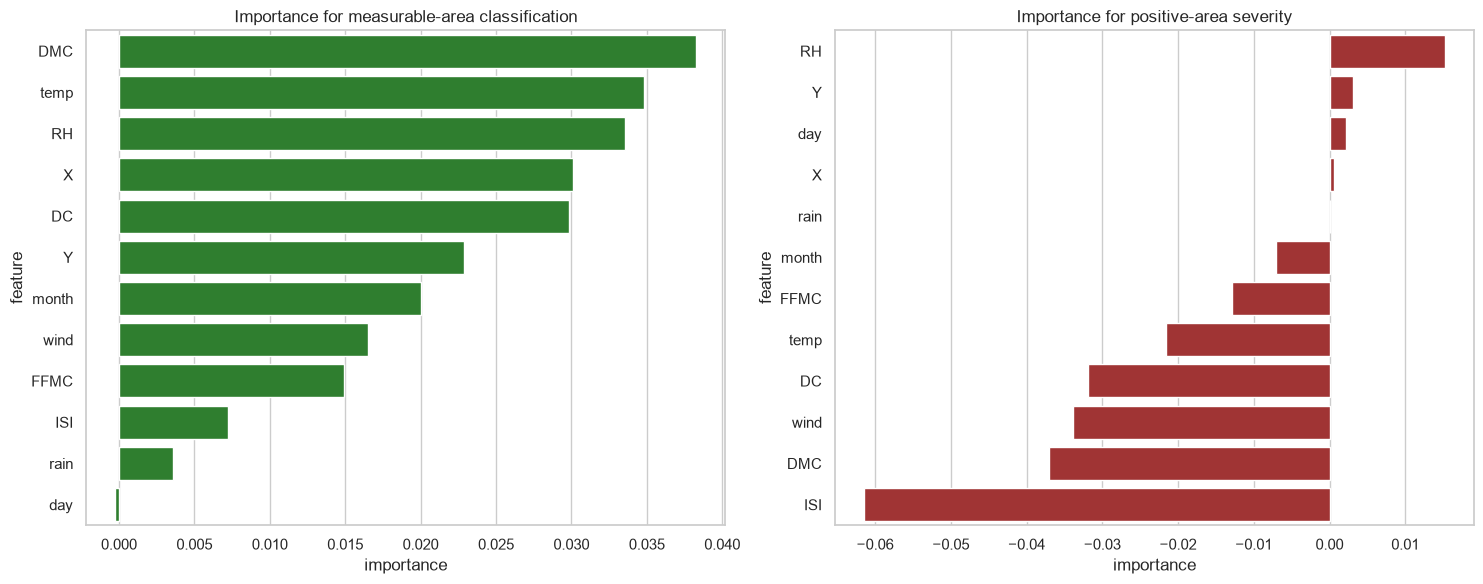

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=classification_importance_df,
    x="importance", y="feature",
    color="forestgreen", ax=axes[0]
)
axes[0].set_title("Importance for measurable-area classification")

sns.barplot(
    data=severity_importance_df,
    x="importance", y="feature",
    color="firebrick", ax=axes[1]
)
axes[1].set_title("Importance for positive-area severity")

plt.tight_layout()
plt.show()

## Final interpretation

### Most influential predictors

For measurable-area classification, the most influential features were:

1. **DMC**
2. **Temperature**
3. **Relative humidity**
4. **X spatial coordinate**
5. **DC**

Month, Y coordinate, wind and FFMC provided smaller positive contributions. Day of the week had approximately zero importance.

For positive-area severity, relative humidity was the only clearly positive feature. Y coordinate and day provided very small positive contributions. Most other features had negative permutation importance, particularly ISI, DMC, wind and DC.

Negative importance does not mean that these variables reduce fire severity. It means that randomly shuffling them improved the model's test performance, which indicates model instability, overfitting or noise. Because the severity model itself performed poorly, its importance ranking should not be treated as reliable scientific evidence.

The two stages used substantially different predictive information. Weather and drought-related variables provided some ability to distinguish zero from positive area, but they did not reliably explain how large a positive fire became.

### Final conclusion

The project successfully implemented a two-stage supervised-learning workflow:

1. Classifying whether burned area was measurable.
2. Predicting the severity of positive-area observations.
3. Combining classification probability and conditional severity.

The classification stage found a modest signal, achieving ROC-AUC 0.6779 and balanced accuracy 0.5897. It was better than the class-prior baseline at ranking cases and recognising both classes, although its accuracy and calibration were limited.

The severity stage was unsuccessful. It performed worse than the median baseline on most metrics and strongly underestimated large fires.

The probability-weighted hurdle slightly improved RMSE and R² compared with the single regression model, but its MAE was worse and its R² remained negative. Therefore, the hurdle structure was methodologically appropriate for the zero-heavy target but could not overcome the limited predictive information and small dataset.

This is still a valid and useful experimental result: it demonstrates that selecting a sensible modelling structure does not guarantee strong prediction when the underlying data contains weak severity signals and extreme outcomes.

### Practical interpretation

This model should not be used as an operational wildfire warning or resource-allocation system. More reliable modelling would require substantially more observations, chronological validation, vegetation and fuel information, terrain, satellite measurements, intervention records and external testing across different fire seasons and locations.